In [ ]:
import numpy as np
import pandas as pd

#Load Dataset And EDA

In [ ]:
np.random.seed(42)
n = 100
size = np.random.randint(500,3500,n)
noise = np.random.randint(0,20000,n)
prices = size * 100 + noise

df = pd.DataFrame({'size': size, 'price' : prices})

df.head()

,size,price
0,1360,138027
1,1794,182095
2,1630,178422
3,1595,164758
4,2138,220536


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   size    100 non-null    int64
 1   price   100 non-null    int64
dtypes: int64(2)
memory usage: 1.7 KB


In [ ]:
df.describe()

,size,price
count,100.000000,100.000000
mean,2018.550000,212136.780000
std,855.173671,86136.206795
min,521.000000,58727.000000
25%,1309.000000,142151.750000
50%,1934.000000,201879.500000
75%,2773.000000,292458.750000
max,3445.000000,361383.000000


In [ ]:
df.isnull().sum()

,0
size,0
price,0


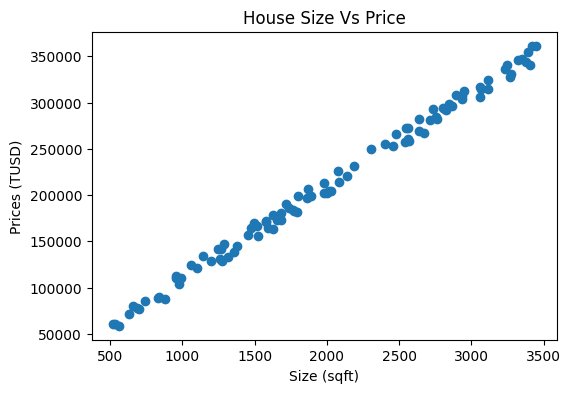

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize = (6,4))
plt.scatter(df['size'], df['price'])
plt.xlabel('Size (sqft)')
plt.ylabel('Prices (TUSD)')
plt.title("House Size Vs Price")
plt.show()

In [ ]:
df['size'].corr(df['price'])

np.float64(0.9975840303505367)

In [ ]:
X = df[['size']]
y = df['price']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
print("Intercept : ", model.intercept_)
print("Coefficient : ", model.coef_)
print(f"Price = {model.intercept_:,.2f} + {model.coef_[0]:,.2f} x Size")

Intercept :  9345.12030580634
Coefficient :  [100.34672247]
Price = 9,345.12 + 100.35 x Size


#Evaluate

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE : {mse:,.2f} \nMAE : {mae:,.2f} \nR^2 : {r2:,.2f}")

MSE : 35,635,024.10 
MAE : 5,267.37 
R^2 : 0.99


#visualize regression

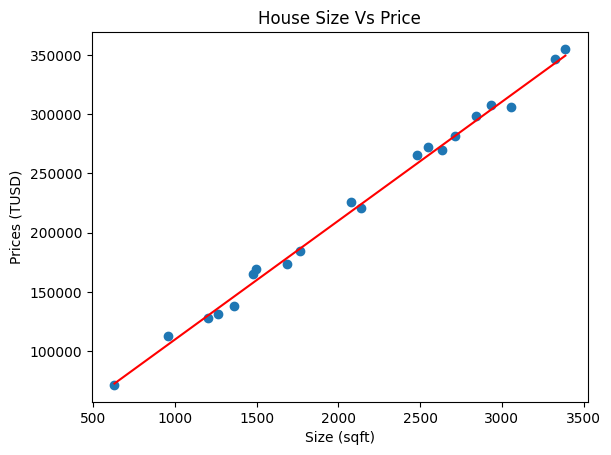

In [ ]:
X_test_sorted = X_test.sort_values(by = "size")

plt.scatter(X_test, y_test)
plt.plot(X_test_sorted, model.predict(X_test_sorted), color = 'red')
plt.xlabel('Size (sqft)')
plt.ylabel('Prices (TUSD)')
plt.title("House Size Vs Price")
plt.show()

#predict new


In [ ]:
new_size = 2700

predict = model.predict(pd.DataFrame([[new_size]], columns = ['size'])
)
predict

array([280281.2709772])